## How well do jobs and skills pay in Europe?

### Methodology:

#### 1. Evaluate median salary
#### 2. Find median salary per skill
#### 3. Visualize for highest paying skills and most demanded skills

In [1]:
# Importing libraries

import ast
import pandas as pd 
import seaborn as sns 
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading data 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
# European jobs filter and droping na values

european_countries = [
    'Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 
    'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Czech Republic', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 
    'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 
    'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 
    'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 
    'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 
    'Ukraine', 'United Kingdom', 'UK', 'Vatican City'
]

# Condition to meet
df_europe = df[df['job_country'].isin(european_countries)]

# Dropping na
df_europe = df_europe.dropna(subset=['salary_year_avg'])
job_titles = df_europe['job_title_short'].value_counts().index.tolist()


['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist',
 'Software Engineer',
 'Senior Data Analyst',
 'Business Analyst',
 'Cloud Engineer']

In [10]:
job_order = df_europe.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

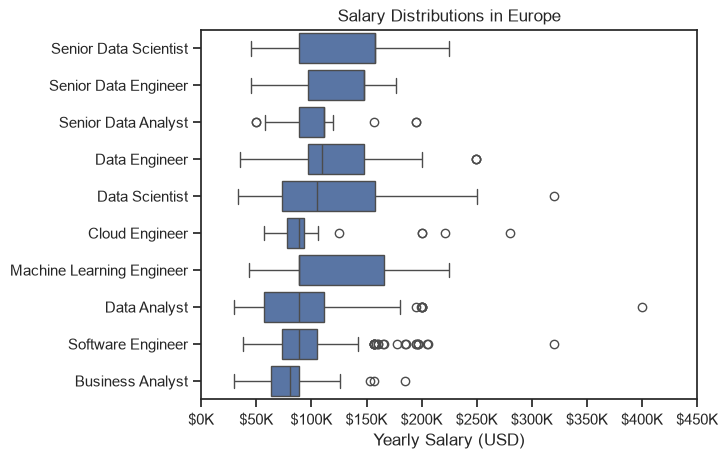

In [13]:
sns.set_theme(style='ticks')

sns.boxplot(
    data=df_europe, 
    x='salary_year_avg', 
    y='job_title_short',
    order=job_order
)

plt.title('Salary Distributions in Europe')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 450000)

ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigate median salary vs skill:

In [14]:
df_europe = df[(df['job_country'].isin(european_countries))].copy()
df_europe = df_europe.dropna(subset=['salary_year_avg'])
df_europe = df_europe.explode('job_skills')
df_europe[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
212,157500.0,c
212,157500.0,r
212,157500.0,sql
212,157500.0,python
212,157500.0,aws


In [ ]:
df_europe_top_pay = df_europe.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_europe_top_pay = df_europe_top_pay.head(10)

In [18]:
df_europe_skills = df_europe.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_europe_skills

,count,median
job_skills,,
python,1179,106439.50
sql,1028,107719.75
aws,511,131580.00
spark,454,132040.00
azure,376,101029.00
...,...,...
react.js,1,75000.00
twilio,1,140000.00
tidyverse,1,56700.00


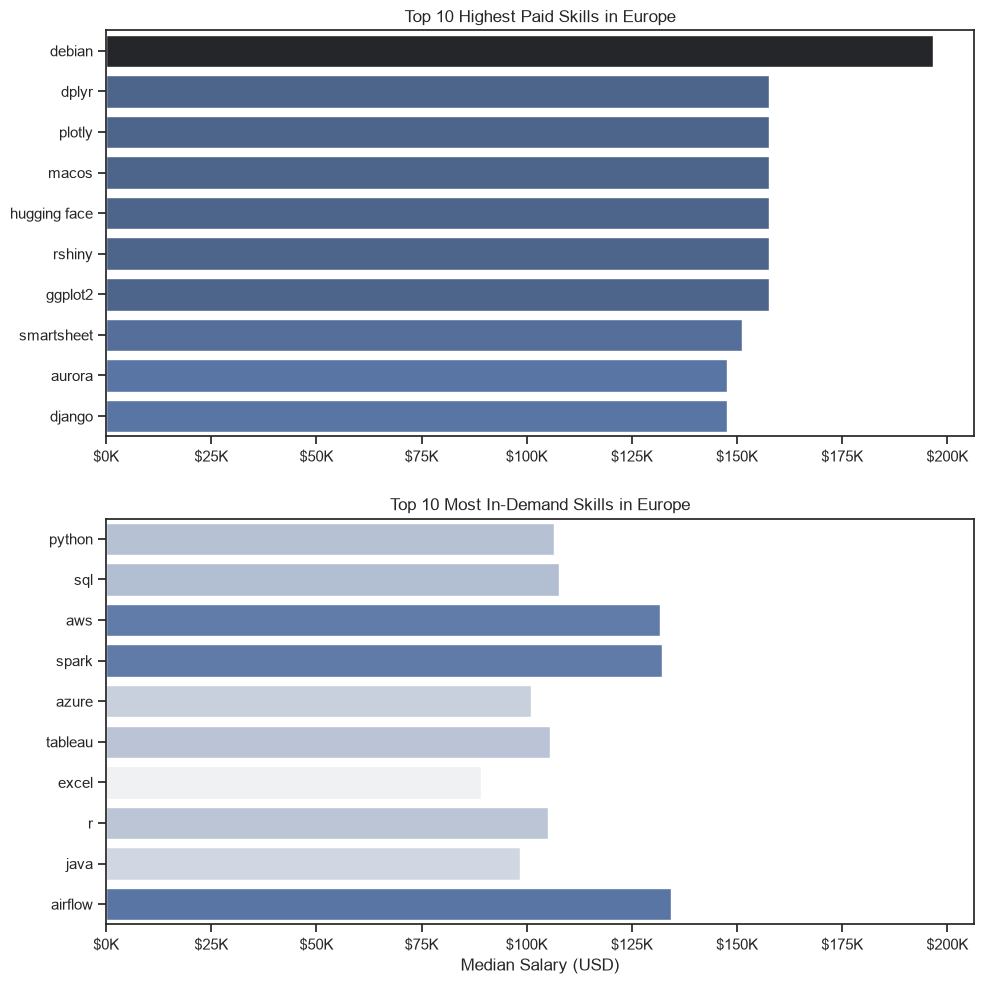

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

sns.set_theme(style='ticks')

# Dodane .head(10) dla pierwszej tabeli
df_europe_top_pay = df_europe_top_pay.head(10)
sns.barplot(data=df_europe_top_pay, x='median', y=df_europe_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r', legend=False)
ax[0].set_title('Top 10 Highest Paid Skills in Europe')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

df_europe_skills = df_europe_skills.head(10)
sns.barplot(data=df_europe_skills, x='median', y=df_europe_skills.index, hue='median', ax=ax[1], palette='light:b', legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills in Europe')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout(h_pad=2.0)
plt.show()